In [9]:
import numpy as np
from scipy.integrate import simpson,trapezoid
from scipy.interpolate import lagrange
import matplotlib.pyplot as plt
from math import e

### a) Solução manual com Polinômio de Lagrange

---

#### **Distância de Pensar – Interpolação de 1ª ordem**



Fórmula do polinômio de Lagrange de 1ª ordem:

$$
L(x) = f(x_0) \cdot \frac{x - x_1}{x_0 - x_1} + f(x_1) \cdot \frac{x - x_0}{x_1 - x_0}
$$

Substituindo \( x = 110 \):

$$
L(110) = 5{,}6 \cdot \frac{110 - 120}{30 - 120} + 22{,}4 \cdot \frac{110 - 30}{120 - 30}
$$

$$
= 5{,}6 \cdot \left( \frac{-10}{-90} \right) + 22{,}4 \cdot \left( \frac{80}{90} \right) = 0{,}6222 + 19{,}9111 = \boxed{20{,}53 \, \text{m}}
$$

---

### Distância de Frear – Interpolação de 2ª ordem

Fórmula do polinômio de Lagrange de 2ª ordem:

$$
L(x) = f(x_0) \cdot \frac{(x - x_1)(x - x_2)}{(x_0 - x_1)(x_0 - x_2)} +
       f(x_1) \cdot \frac{(x - x_0)(x - x_2)}{(x_1 - x_0)(x_1 - x_2)} +
       f(x_2) \cdot \frac{(x - x_0)(x - x_1)}{(x_2 - x_0)(x_2 - x_1)}
$$

Substituindo \( x = 110 \):

$$
L(110) = 5{,}0 \cdot \frac{(110 - 60)(110 - 120)}{(30 - 60)(30 - 120)} +
         21{,}0 \cdot \frac{(110 - 30)(110 - 120)}{(60 - 30)(60 - 120)} +
         84{,}7 \cdot \frac{(110 - 30)(110 - 60)}{(120 - 30)(120 - 60)}
$$

$$
= 5{,}0 \cdot \frac{50 \cdot (-10)}{-30 \cdot -90} +
   21{,}0 \cdot \frac{80 \cdot (-10)}{30 \cdot (-60)} +
   84{,}7 \cdot \frac{80 \cdot 50}{90 \cdot 60}
$$

$$
= 5{,}0 \cdot \frac{-500}{2700} +
   21{,}0 \cdot \frac{-800}{-1800} +
   84{,}7 \cdot \frac{4000}{5400}
$$

$$
= -0{,}926 + 9{,}333 + 62{,}74 = \boxed{71{,}15 \, \text{m}}
$$

### Distância Total de Parada a 110 km/h

A distância total para parar um automóvel é a soma da distância de **pensar** e de **frear**.

Sabemos que:

- Distância de pensar : 20.53
- Distância de frear 71.15

Portanto:

$$
\text{Distância Total} = 20{,}53 + 71{,}15 = \boxed{91{,}68 \, \text{m}}
$$

In [30]:
pensar = np.array([5.6,8.5,11.1,14.5,16.7,22.4])
frear = np.array([5,12.3,21,32.9,47.6,84.7])
velocidade = np.array([30,45,60,75,90,120])

interpolador_pensar = lagrange(velocidade, pensar)
interpolador_frear = lagrange(velocidade, frear)



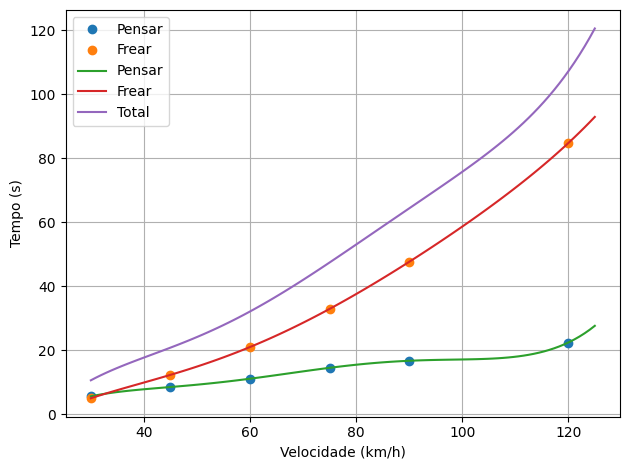

In [42]:
space = np.linspace(30, 125, 100)
plt.plot(velocidade, pensar, 'o', label='Pensar')
plt.plot(velocidade, frear, 'o', label='Frear')
plt.plot(space, interpolador_pensar(space), label='Pensar')
plt.plot(space, interpolador_frear(space), label='Frear')  
plt.plot(space, interpolador_pensar(space) + interpolador_frear(space), label='Total')
plt.xlabel('Velocidade (km/h)')
plt.ylabel('Tempo (s)')
plt.grid()
plt.tight_layout()
plt.legend()

In [32]:
resposta = interpolador_pensar(110) + interpolador_frear(110)

print(f'Distancia de parada total para um carro a 110Km/h: {resposta:.3}m')

Distancia de parada total para um carro a 110Km/h: 88.7m


## Estimativa do rendimento \( R \) para \( H/h = 7,67 \)

Dado que:

- Altura de recalque \( H = 46 \, \text{m} \)
- Altura de queda \( h = 6 \, \text{m} \)

Temos:

$$
\frac{H}{h} = \frac{46}{6} \approx 7,67
$$

Para esse valor intermediário, será necessário interpolar a razão \( R \) da tabela fornecida usando dois métodos: Lagrange e Newton (ambos de 2ª ordem).

---

### Interpolação com Polinômio de Lagrange (2ª ordem)


Fórmula de Lagrange:

$$
L(x) = f(x_0) \cdot \frac{(x - x_1)(x - x_2)}{(x_0 - x_1)(x_0 - x_2)} +
       f(x_1) \cdot \frac{(x - x_0)(x - x_2)}{(x_1 - x_0)(x_1 - x_2)} +
       f(x_2) \cdot \frac{(x - x_0)(x - x_1)}{(x_2 - x_0)(x_2 - x_1)}
$$

Substituindo \( x = 7.67 \):

$$
\begin{aligned}
L(7.67) &= 0.6214 \cdot \frac{(7.67 - 7.5)(7.67 - 8.0)}{(7.0 - 7.5)(7.0 - 8.0)} \\
&\quad + 0.5940 \cdot \frac{(7.67 - 7.0)(7.67 - 8.0)}{(7.5 - 7.0)(7.5 - 8.0)} \\
&\quad + 0.5663 \cdot \frac{(7.67 - 7.0)(7.67 - 7.5)}{(8.0 - 7.0)(8.0 - 7.5)} \\
&\approx \boxed{0.5834}
\end{aligned}
$$

---

### Interpolação com Polinômio de Newton (2ª ordem)

Fórmula do polinômio de Newton:

$$
P(x) = f(x_0) + f[x_0,x_1](x - x_0) + f[x_0,x_1,x_2](x - x_0)(x - x_1)
$$

Cálculo das diferenças divididas:

\[
f[x_0,x_1] = \frac{0.5940 - 0.6214}{7.5 - 7.0} = -0.0548
\]
\[
f[x_1,x_2] = \frac{0.5663 - 0.5940}{8.0 - 7.5} = -0.0554
\]
\[
f[x_0,x_1,x_2] = \frac{-0.0554 - (-0.0548)}{8.0 - 7.0} = -0.0003
\]

Substituindo \( x = 7.67 \):

$$
\begin{aligned}
P(7.67) &= 0.6214 + (-0.0548)(0.67) + (-0.0003)(0.67)(0.17) \\
&\approx \boxed{0.5847}
\end{aligned}
$$

---

### Comparação dos métodos

| Método        | Valor estimado de \( R \) |
|---------------|---------------------------|
| Lagrange (2ª) |           0.5834          |
| Newton (2ª)   |           0.5847          |

In [47]:
Hh = np.array([6,6.5,7,7.5,8,8.5,9])
R = np.array([0.6728,0.6476,0.6214,0.5940,0.5653,0.5350,0.5029])


interpolador_Hh = lagrange(Hh, R)


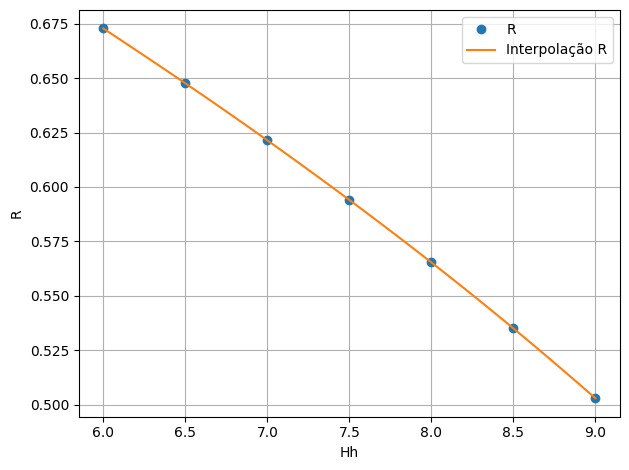

In [48]:
space = np.linspace(6, 9, 100)
plt.plot(Hh, R, 'o', label='R')    
plt.plot(space, interpolador_Hh(space), label='Interpolação R')
plt.xlabel('Hh')
plt.ylabel('R')
plt.grid()
plt.tight_layout()
plt.legend()

In [49]:
resposta = interpolador_Hh(7.67)

print(f'R para Hh=7.67: {resposta:.3}')

R para Hh=7.67: 0.584


In [50]:
def newton_divided_diff(x, y):
    n = len(x)
    coef = np.copy(y)
    for j in range(1, n):
        coef[j:n] = (coef[j:n] - coef[j - 1]) / (x[j:n] - x[j - 1])
    return coef

def newton_interpolate(x_data, coef, x_val):
    n = len(coef)
    result = coef[0]
    for i in range(1, n):
        term = coef[i]
        for j in range(i):
            term *= (x_val - x_data[j])
        result += term
    return result


coef = newton_divided_diff(Hh[2:5], R[2:5])


x_interp = 7.67
R_interp = newton_interpolate(Hh[2:5], coef, x_interp)

print(f"Coeficientes de Newton: {coef}")
print(f"R interpolado em Hh = 7.67: {R_interp:.3f}")

Coeficientes de Newton: [ 0.6214 -0.0548 -0.0026]
R interpolado em Hh = 7.67: 0.584


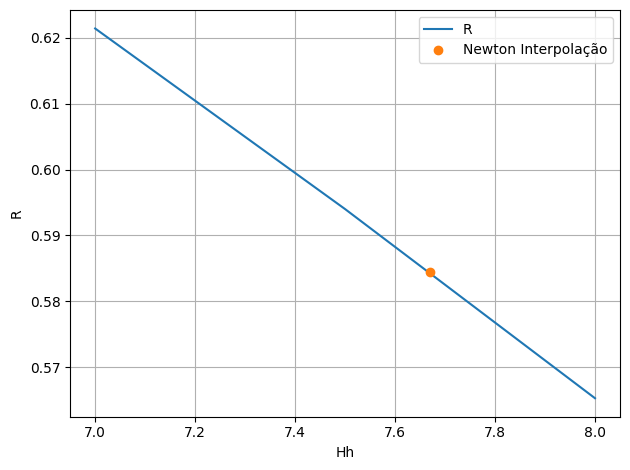

In [52]:
plt.plot(Hh[2:5], R[2:5], label='R')
plt.plot(x_interp, R_interp, 'o', label='Newton Interpolação')
plt.xlabel('Hh')
plt.ylabel('R')
plt.grid()
plt.tight_layout()
plt.legend()

## Questão 4 – Cálculo da Integral

Calcular:

$$
\int_0^3 (1 - e^{-2x}) \, dx
$$

---

### c) Regra do Trapézio Composta

#### Para n = 2 (três pontos)

Dividimos o intervalo [0, 3] em dois subintervalos:  
\( x_0 = 0, \quad x_1 = 1.5, \quad x_2 = 3 \)

$$
h = \frac{3 - 0}{2} = 1.5
$$

Aplicamos a fórmula da regra do trapézio composta:

$$
T_2 = \frac{h}{2} \left[ f(x_0) + 2f(x_1) + f(x_2) \right]
$$

Substituindo:

$$
T_2 = \frac{1.5}{2} \left[ (1 - e^0) + 2(1 - e^{-3}) + (1 - e^{-6}) \right]
$$

$$
= 0.75 \cdot \left[ 0 + 2(1 - e^{-3}) + (1 - e^{-6}) \right]
$$

$$
\approx 0.75 \cdot \left[ 2(0.9502) + 0.9975 \right] = 0.75 \cdot 2.8979 = \boxed{2.173}
$$

---

#### Para n = 4 (cinco pontos)

Dividimos o intervalo em 4 subintervalos:

$$
h = \frac{3 - 0}{4} = 0.75
$$

Pontos:

$$
x = [0, 0.75, 1.5, 2.25, 3]
$$

Fórmula:

$$
T_4 = \frac{h}{2} \left[ f(x_0) + 2f(x_1) + 2f(x_2) + 2f(x_3) + f(x_4) \right]
$$

Substituindo:

$$
T_4 = 0.375 \cdot \left[ f(0) + 2f(0.75) + 2f(1.5) + 2f(2.25) + f(3) \right]
$$

Com \( f(x) = 1 - e^{-2x} \), substituímos os valores:

$$
T_4 \approx 0.375 \cdot \left( 0 + 2 \cdot 0.7769 + 2 \cdot 0.9502 + 2 \cdot 0.9876 + 0.9975 \right)
$$

$$
= 0.375 \cdot (1.5538 + 1.9004 + 1.9752 + 0.9975) = 0.375 \cdot 6.4269 = \boxed{2.410}
$$

---

### d) Regra de Simpson 1/3 (Única Aplicação)

Usamos os pontos:

$$
x = [0, 1.5, 3], \quad h = \frac{3 - 0}{2} = 1.5
$$

Fórmula:

$$
S = \frac{h}{3} \left[ f(x_0) + 4f(x_1) + f(x_2) \right]
$$

Substituindo:

$$
S = \frac{1.5}{3} \left[ f(0) + 4f(1.5) + f(3) \right]
$$

$$
= 0.5 \cdot \left[ 0 + 4(0.9502) + 0.9975 \right] = 0.5 \cdot 4.7983 = \boxed{2.399}
$$

---

### e) Regra de Simpson 1/3 Composta (n = 4)

Pontos:

$$
x = [0, 0.75, 1.5, 2.25, 3], \quad h = 0.75
$$

Fórmula:

$$
S = \frac{h}{3} \left[ f(x_0) + 4f(x_1) + 2f(x_2) + 4f(x_3) + f(x_4) \right]
$$

Substituindo os valores:

$$
S = 0.25 \cdot \left[ 0 + 4(0.7769) + 2(0.9502) + 4(0.9876) + 0.9975 \right]
$$

$$
= 0.25 \cdot (3.1076 + 1.9004 + 3.9504 + 0.9975) = 0.25 \cdot 9.956 = \boxed{2.489}
$$

---

### f) Regra de Simpson 3/8 (Única Aplicação)

Usamos 4 pontos igualmente espaçados:

$$
x = [0, 1, 2, 3], \quad h = 1
$$

Fórmula:

$$
S = \frac{3h}{8} \left[ f(x_0) + 3f(x_1) + 3f(x_2) + f(x_3) \right]
$$

Substituindo os valores:

$$
S = \frac{3}{8} \cdot \left[ 0 + 3(0.8647) + 3(0.9817) + 0.9975 \right]
$$

$$
= \frac{3}{8} \cdot (2.5941 + 2.9451 + 0.9975) = \frac{3}{8} \cdot 6.5367 = \boxed{2.451}
$$


In [ ]:
f = lambda x: 1 - np.exp(-2 * x)

I_exact = (5 + 1/e**6)/2

def erro_percentual(aprox, real):
    return abs((aprox - real) / real) * 100

# (b) 
x_b = np.array([0, 3])
y_b = f(x_b)
T1 = trapezoid(y_b, x_b)
err_b = erro_percentual(T1, I_exact)

# (c) 
x_c2 = np.linspace(0, 3, 3)
T2 = trapezoid(f(x_c2), x_c2)
err_c2 = erro_percentual(T2, I_exact)

x_c4 = np.linspace(0, 3, 5)
T4 = trapezoid(f(x_c4), x_c4)
err_c4 = erro_percentual(T4, I_exact)

# (d) 
x_d = np.array([0, 1.5, 3])
S1 = simpson(f(x_d), x = x_d)
err_d = erro_percentual(S1, I_exact)

# (e) 
x_e = np.linspace(0, 3, 5)
S4 = simpson(f(x_e), x = x_e)
err_e = erro_percentual(S4, I_exact)

# (f) 
x_f = np.linspace(0, 3, 4)  
y_f = f(x_f)
h = x_f[1] - x_f[0]
S38 = 3 * h / 8 * (y_f[0] + 3*y_f[1] + 3*y_f[2] + y_f[3])
err_f = erro_percentual(S38, I_exact)

# (g) 
x_g = np.linspace(0, 3, 6)  
S5 = simpson(f(x_g),x =  x_g)
err_g = erro_percentual(S5, I_exact)

print(f"Valor exato (a mão):       {I_exact:.6f}\n")
print(f"(b) Trapézio (única):      {T1:.6f} | Erro: {err_b:.4f}%")
print(f"(c) Trapézio n=2:          {T2:.6f} | Erro: {err_c2:.4f}%")
print(f"(c) Trapézio n=4:          {T4:.6f} | Erro: {err_c4:.4f}%")
print(f"(d) Simpson 1/3 única:     {S1:.6f} | Erro: {err_d:.4f}%")
print(f"(e) Simpson 1/3 n=4:       {S4:.6f} | Erro: {err_e:.4f}%")
print(f"(f) Simpson 3/8 única:     {S38:.6f} | Erro: {err_f:.4f}%")
print(f"(g) Simpson geral n=5:     {S5:.6f} | Erro: {err_g:.4f}%")

Valor exato (a mão):       2.501239

(b) Trapézio (única):      1.496282 | Erro: 40.1784%
(c) Trapézio n=2:          2.173460 | Erro: 13.1047%
(c) Trapézio n=4:          2.411051 | Erro: 3.6058%
(d) Simpson 1/3 única:     2.399186 | Erro: 4.0801%
(e) Simpson 1/3 n=4:       2.490248 | Erro: 0.4395%
(f) Simpson 3/8 única:     2.451213 | Erro: 2.0001%
(g) Simpson geral n=5:     2.496707 | Erro: 0.1812%


Questão 5


In [ ]:
y = np.array([0, 1, 3, 5, 7, 8, 9, 10])  
H = np.array([0, 1, 1.5, 3, 3.5, 3.2, 2, 0])  
U = np.array([0, 0.1, 0.12, 0.2, 0.25, 0.3, 0.15, 0])  

profundidade_media = np.mean(H)

Ac = trapezoid(H, y)

HU = H * U
Q = np.mean(HU)

velocidade_media = np.mean(U)

print(f"Profundidade média                   = {profundidade_media:.4f} m")
print(f"Área da seção Transversal (Ac)       = {Ac:.4f} m²")
print(f"Velocidade média                     = {velocidade_media:.4f} m/s")
print(f"Taxa de Escoamento                   = {Q:.4f} m³/s")

Profundidade média                   = 1.7750 m
Área da seção Transversal (Ac)       = 20.9500 m²
Velocidade média                     = 0.1400 m/s
Taxa de Escoamento                   = 0.3769 m³/s
